# Query Cloud SQL Database

Connect to the remote tracking analytics database via Cloud SQL Proxy and explore the data.

## Prerequisites

### 1. Install gcloud CLI
```bash
# macOS
brew install google-cloud-sdk

# Or download from: https://cloud.google.com/sdk/docs/install
```

### 2. Install Cloud SQL Auth Proxy
```bash
# macOS (Apple Silicon)
curl -o cloud-sql-proxy https://storage.googleapis.com/cloud-sql-connectors/cloud-sql-proxy/v2.14.3/cloud-sql-proxy.darwin.arm64
chmod +x cloud-sql-proxy
sudo mv cloud-sql-proxy /usr/local/bin/

# macOS (Intel)
curl -o cloud-sql-proxy https://storage.googleapis.com/cloud-sql-connectors/cloud-sql-proxy/v2.14.3/cloud-sql-proxy.darwin.amd64
chmod +x cloud-sql-proxy
sudo mv cloud-sql-proxy /usr/local/bin/
```

### 3. Authenticate with Google Cloud
```bash
# Login
gcloud auth login
gcloud auth application-default login

# Set project
gcloud config set project collab-data-463313
```

### 4. Install the package (from current branch)
```bash
# Install from GitHub with the db-eda-dashboard branch
pip install "collab-env[db] @ git+https://github.com/BasisResearch/collab-environment.git@db-eda-dashboard"
```

**Note**: The SQL query files are included in the package distribution via `package-data` configuration in `pyproject.toml`. If you encounter "queries directory not found" errors, ensure you're installing from a commit that includes the `[tool.setuptools.package-data]` section.

### 5. Start the Cloud SQL Proxy (in a separate terminal)
```bash
# From the repo root:
source scripts/deploy/config.sh
./scripts/deploy/start_proxy.sh

# Or manually:
cloud-sql-proxy collab-data-463313:us-central1:spatial-analysis-db --port 5433
```

Keep the proxy running while using this notebook.

## Setup Environment Variables

### Verify Installation

Run this cell first to verify that SQL query files are accessible:

In [1]:
from pathlib import Path
import collab_env.data.db.query_backend

# Check if queries directory exists
queries_dir = Path(collab_env.data.db.query_backend.__file__).parent / "queries"
if queries_dir.exists():
    sql_files = list(queries_dir.glob("*.sql"))
    print(f"✓ SQL queries directory found: {queries_dir}")
    print(f"✓ Found {len(sql_files)} SQL files:")
    for f in sorted(sql_files):
        print(f"  - {f.name}")
else:
    print(f"✗ ERROR: Queries directory not found at {queries_dir}")
    print("\nThis means the package was not installed with the SQL files included.")
    print(
        "Please ensure you're installing from a commit that includes the package-data configuration."
    )
    raise FileNotFoundError(f"Queries directory not found: {queries_dir}")

✓ SQL queries directory found: /Users/dima/git/collab-environment.worktrees/db-eda-dashboard/collab_env/data/db/queries
✓ Found 4 SQL files:
  - basic_data_viewer.sql
  - correlations.sql
  - session_metadata.sql
  - spatial_analysis.sql


In [2]:
import os
import subprocess

# Get password from Secret Manager
result = subprocess.run(
    ["gcloud", "secrets", "versions", "access", "latest", "--secret=postgres-password"],
    capture_output=True,
    text=True,
)
if result.returncode != 0:
    raise RuntimeError(f"Failed to get password: {result.stderr}")

# Set environment variables for database connection
os.environ["DB_BACKEND"] = "postgres"
os.environ["POSTGRES_HOST"] = "localhost"
os.environ["POSTGRES_PORT"] = "5433"
os.environ["POSTGRES_DB"] = "tracking_analytics"
os.environ["POSTGRES_USER"] = "postgres"
os.environ["POSTGRES_PASSWORD"] = result.stdout.strip()

print("Environment configured for Cloud SQL via proxy on localhost:5433")

Environment configured for Cloud SQL via proxy on localhost:5433


## Connect to Database

In [3]:
from collab_env.data.db.query_backend import QueryBackend

# Initialize query backend (reads config from environment)
query = QueryBackend()
print("Connected to Cloud SQL database")

2026-02-23 15:27:28 | INFO     | collab_env.data.db.db_loader:connect:223 - Connected to PostgreSQL: tracking_analytics
2026-02-23 15:27:28 | INFO     | collab_env.data.db.query_backend:__init__:87 - Loaded queries from /Users/dima/git/collab-environment.worktrees/db-eda-dashboard/collab_env/data/db/queries using psycopg2 adapter


Connected to Cloud SQL database


## Explore Sessions and Episodes

In [4]:
# Get all categories
categories = query.get_categories()
print("Available categories:")
categories

2026-02-23 15:27:28 | INFO     | collab_env.data.db.query_backend:_execute_query:112 - Executing query 'get_categories' with params: {}
2026-02-23 15:27:28 | INFO     | collab_env.data.db.query_backend:_execute_query:145 - Query 'get_categories' completed in 0.074s: 5 rows returned


Available categories:


,category_id,category_name,description
0,boids_2d_rollout,2D Boids GNN Rollout,GNN model predictions on 2D boids test data
1,boids_2d,2D Boids Simulations,Sessions from 2D boid simulations
2,boids_3d,3D Boids Simulations,Sessions from 3D boid simulations
3,particle-sim,Particle Simulations,McKean-Vlasov particle system simulations
4,tracking_csv,Real-World Tracking,Sessions from video tracking (CSV data)


In [12]:
# Get sessions (optionally filter by category)
sessions = query.get_sessions(category_id="boids_2d")
print(f"Found {len(sessions)} sessions:")
sessions[["session_id", "session_name", "category_id"]]

2026-02-23 15:29:34 | INFO     | collab_env.data.db.query_backend:_execute_query:112 - Executing query 'get_sessions' with params: {'category_id': 'boids_2d'}
2026-02-23 15:29:34 | INFO     | collab_env.data.db.query_backend:_execute_query:145 - Query 'get_sessions' completed in 0.072s: 1 rows returned


Found 1 sessions:


,session_id,session_name,category_id
0,session-2d-boid_food_basic,boid_food_basic,boids_2d


In [13]:
# Select a session and get its episodes
session_id = sessions.iloc[0]["session_id"]
print(f"Selected session: {session_id}")

episodes = query.get_episodes(session_id)
print(f"\nFound {len(episodes)} episodes:")
episodes[["episode_id", "episode_number", "num_frames", "num_agents", "frame_rate"]]

2026-02-23 15:29:39 | INFO     | collab_env.data.db.query_backend:_execute_query:112 - Executing query 'get_episodes' with params: {'session_id': 'session-2d-boid_food_basic'}
2026-02-23 15:29:39 | INFO     | collab_env.data.db.query_backend:_execute_query:145 - Query 'get_episodes' completed in 0.090s: 20 rows returned


Selected session: session-2d-boid_food_basic

Found 20 episodes:


,episode_id,episode_number,num_frames,num_agents,frame_rate
0,episode-0000-session-2d-boid_food_basic,0,1200,21,1.0
1,episode-0001-session-2d-boid_food_basic,1,1200,21,1.0
2,episode-0002-session-2d-boid_food_basic,2,1200,21,1.0
3,episode-0003-session-2d-boid_food_basic,3,1200,21,1.0
4,episode-0004-session-2d-boid_food_basic,4,1200,21,1.0
5,episode-0005-session-2d-boid_food_basic,5,1200,21,1.0
6,episode-0006-session-2d-boid_food_basic,6,1200,21,1.0
7,episode-0007-session-2d-boid_food_basic,7,1200,21,1.0
8,episode-0008-session-2d-boid_food_basic,8,1200,21,1.0
9,episode-0009-session-2d-boid_food_basic,9,1200,21,1.0


## Query Tracks

In [14]:
# Get tracks for an episode (first 100 frames)
episode_id = episodes.iloc[0]["episode_id"]
print(f"Getting tracks for episode: {episode_id}")

tracks = query.get_episode_tracks(episode_id=episode_id, start_time=0, end_time=100)
print(f"\nLoaded {len(tracks)} track points")
tracks.head(10)

2026-02-23 15:29:42 | INFO     | collab_env.data.db.query_backend:_execute_query:112 - Executing query 'get_episode_tracks' with params: {'episode_id': 'episode-0000-session-2d-boid_food_basic', 'start_time': 0, 'end_time': 100, 'agent_type': 'agent'}


Getting tracks for episode: episode-0000-session-2d-boid_food_basic


2026-02-23 15:29:42 | INFO     | collab_env.data.db.query_backend:_execute_query:145 - Query 'get_episode_tracks' completed in 0.406s: 2121 rows returned



Loaded 2121 track points


,agent_id,time_index,x,y,z,v_x,v_y,v_z,speed
0,0,0,222.881653,455.844086,None,-4.772372,1.929560,None,5.147692
1,1,0,252.075439,164.408844,None,-4.380598,-5.459862,None,6.999981
2,2,0,270.883850,290.224609,None,-2.007265,-3.296385,None,3.859439
3,3,0,18.592907,209.729843,None,1.215878,1.457620,None,1.898160
4,4,0,439.884674,70.365395,None,0.253172,-1.517622,None,1.538595
5,5,0,381.064545,430.051025,None,0.104399,-1.212645,None,1.217130
6,6,0,259.025208,110.972130,None,-5.000553,-4.898422,None,7.000005
7,7,0,3.379142,202.803513,None,3.100648,2.424216,None,3.935841
8,8,0,425.302124,242.026611,None,-2.171059,-1.585178,None,2.688175
9,9,0,444.316650,46.915905,None,-0.360689,-1.710945,None,1.748551


In [15]:
# Basic track statistics
print(f"Time range: {tracks['time_index'].min()} - {tracks['time_index'].max()}")
print(f"Unique agents: {tracks['agent_id'].nunique()}")
print("\nSpeed statistics:")
tracks["speed"].describe()

Time range: 0 - 100
Unique agents: 21

Speed statistics:


count    2121.000000
mean        2.473925
std         2.489460
min         0.000000
25%         0.511849
50%         1.141560
75%         4.218965
max         7.000042
Name: speed, dtype: float64

## Visualize Tracks

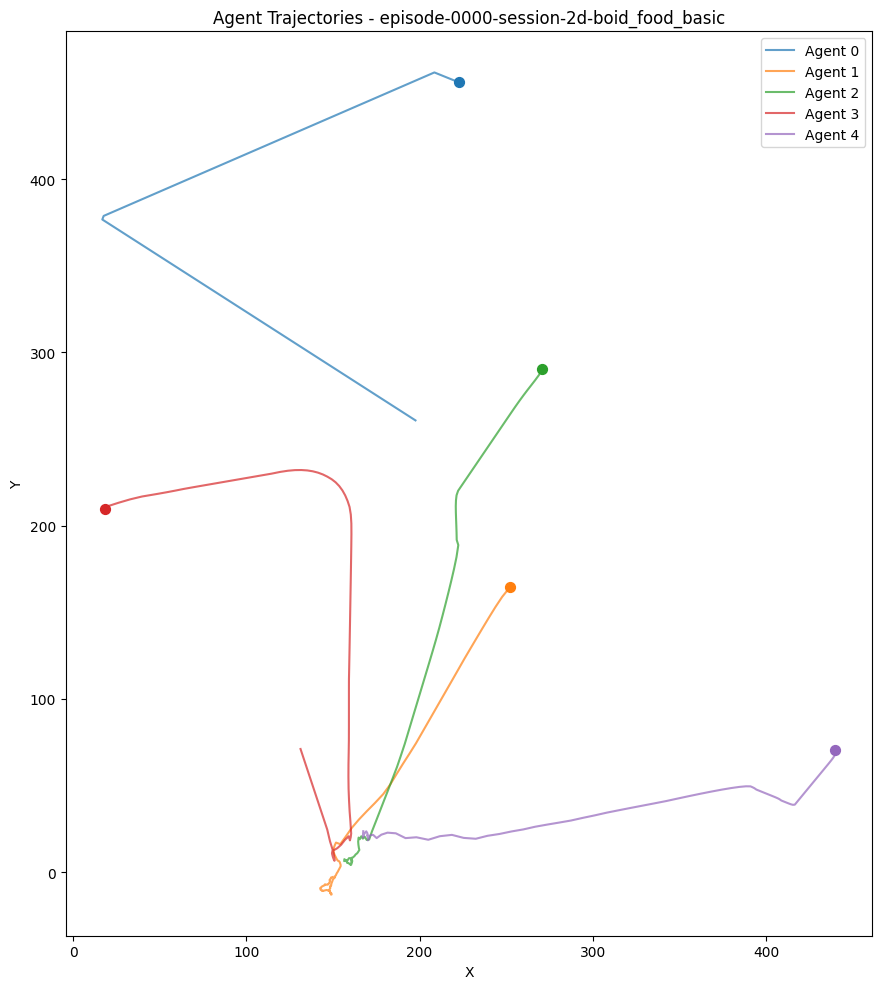

In [16]:
import matplotlib.pyplot as plt

# Plot XY trajectories for first 5 agents
fig, ax = plt.subplots(figsize=(10, 10))

agent_ids = tracks["agent_id"].unique()[:5]
for agent_id in agent_ids:
    agent_tracks = tracks[tracks["agent_id"] == agent_id]
    ax.plot(
        agent_tracks["x"], agent_tracks["y"], "-", alpha=0.7, label=f"Agent {agent_id}"
    )
    # Mark start position
    ax.scatter(agent_tracks["x"].iloc[0], agent_tracks["y"].iloc[0], s=50, marker="o")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title(f"Agent Trajectories - {episode_id}")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

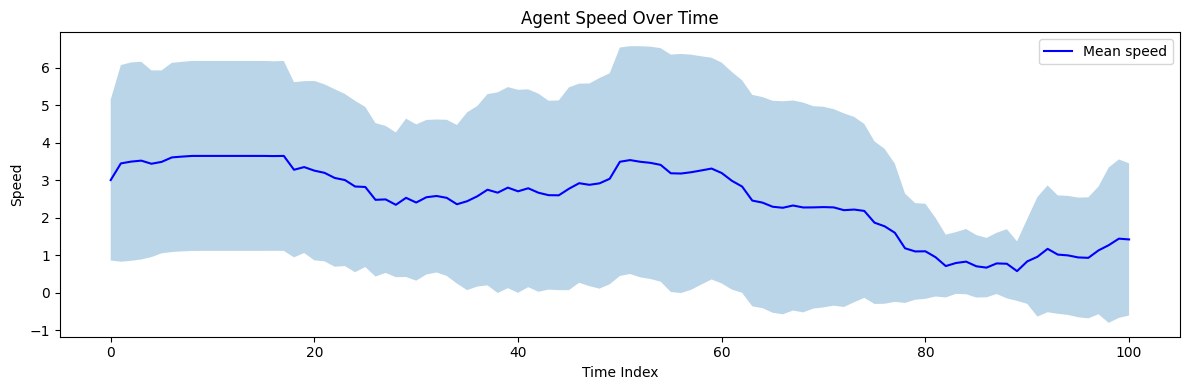

In [17]:
# Speed over time for all agents
fig, ax = plt.subplots(figsize=(12, 4))

# Compute mean speed per time step
speed_by_time = tracks.groupby("time_index")["speed"].agg(["mean", "std"])
ax.fill_between(
    speed_by_time.index,
    speed_by_time["mean"] - speed_by_time["std"],
    speed_by_time["mean"] + speed_by_time["std"],
    alpha=0.3,
)
ax.plot(speed_by_time.index, speed_by_time["mean"], "b-", label="Mean speed")

ax.set_xlabel("Time Index")
ax.set_ylabel("Speed")
ax.set_title("Agent Speed Over Time")
ax.legend()
plt.tight_layout()
plt.show()

## Spatial Heatmap

In [18]:
# Get spatial heatmap (binned positions)
heatmap = query.get_spatial_heatmap(episode_id=episode_id, bin_size=20.0)
print(f"Heatmap has {len(heatmap)} bins")
heatmap.head()

2026-02-23 15:30:01 | INFO     | collab_env.data.db.query_backend:_execute_query:112 - Executing query 'get_spatial_heatmap_episode' with params: {'episode_id': 'episode-0000-session-2d-boid_food_basic', 'bin_size': 20.0, 'start_time': None, 'end_time': None, 'agent_type': 'agent', 'min_count': 1}
2026-02-23 15:30:02 | INFO     | collab_env.data.db.query_backend:_execute_query:145 - Query 'get_spatial_heatmap_episode' completed in 0.744s: 513 rows returned


Heatmap has 513 bins


,x_bin,y_bin,z_bin,density,avg_vx,avg_vy,avg_vz
0,0.0,200.0,None,5,4.895408,1.753381,None
1,0.0,240.0,None,2,2.384337,5.852752,None
2,0.0,340.0,None,5,3.073229,0.733881,None
3,0.0,360.0,None,3,1.351132,0.811396,None
4,0.0,380.0,None,3,2.226737,-3.075686,None


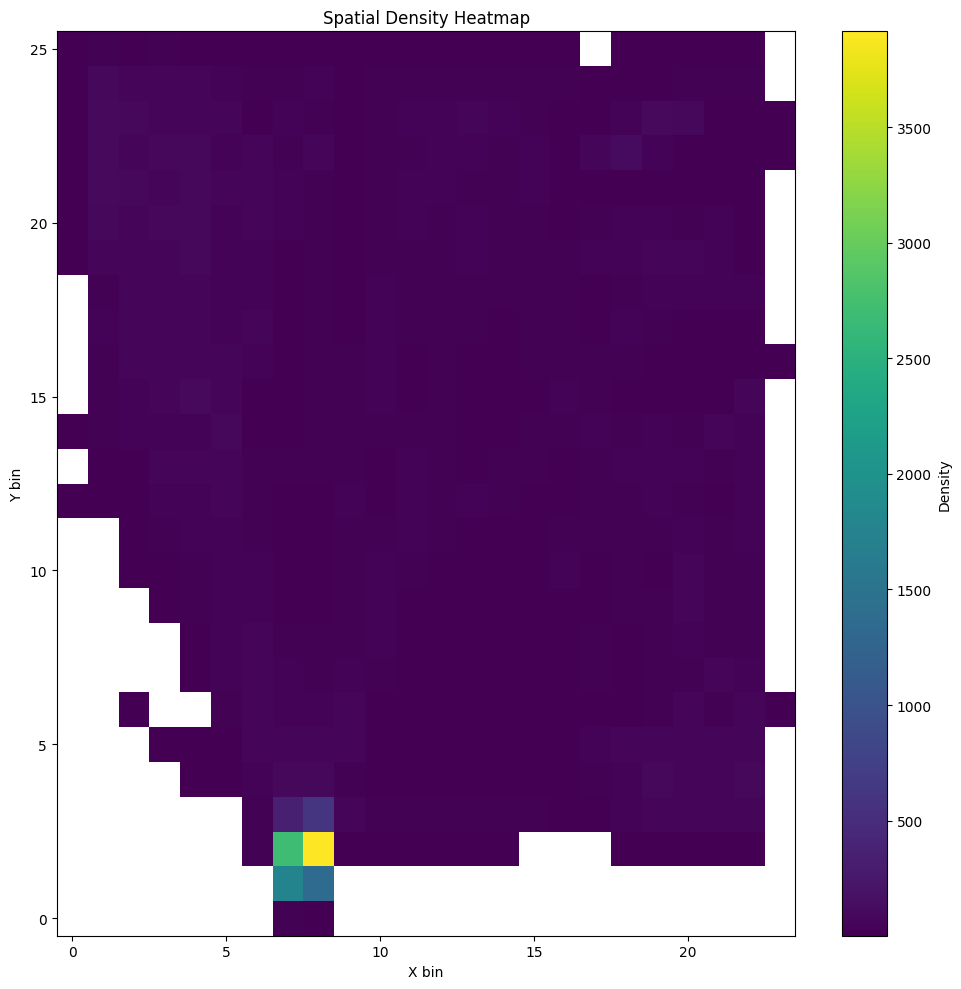

In [19]:
# Plot 2D heatmap (XY)
import numpy as np

# Aggregate z dimension
heatmap_2d = heatmap.groupby(["x_bin", "y_bin"])["density"].sum().reset_index()

# Create 2D grid
pivot = heatmap_2d.pivot(index="y_bin", columns="x_bin", values="density")

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(pivot.values, origin="lower", cmap="viridis", aspect="auto")
ax.set_xlabel("X bin")
ax.set_ylabel("Y bin")
ax.set_title("Spatial Density Heatmap")
plt.colorbar(im, ax=ax, label="Density")
plt.tight_layout()
plt.show()

## Animated Track Visualization

Interactive animation with timeline slider and play controls using Plotly.

In [20]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Select subset of agents for clarity
num_agents_to_plot = 10
selected_agents = tracks["agent_id"].unique()[:num_agents_to_plot]
tracks_anim = tracks[tracks["agent_id"].isin(selected_agents)].copy()

# Setup figure
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(tracks["x"].min() - 20, tracks["x"].max() + 20)
ax.set_ylim(tracks["y"].min() - 20, tracks["y"].max() + 20)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal")
ax.set_title("Agent Tracks Animation")

# Create scatter and trail objects for each agent
scatters = {}
trails = {}
colors = plt.get_cmap("tab10")(np.linspace(0, 1, num_agents_to_plot))

for i, agent_id in enumerate(selected_agents):
    scatters[agent_id] = ax.scatter(
        [], [], s=100, c=[colors[i]], label=f"Agent {agent_id}", zorder=3
    )
    (trails[agent_id],) = ax.plot([], [], "-", c=colors[i], alpha=0.4, linewidth=2)

ax.legend(loc="upper right", fontsize=8)
time_text = ax.text(
    0.02,
    0.98,
    "",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Animation parameters
trail_length = 20  # Number of frames to show in trail


def animate(frame_idx):
    """Update function for each frame."""
    time_indices = sorted(tracks_anim["time_index"].unique())
    time_index = time_indices[frame_idx]

    for agent_id in selected_agents:
        # Get trail data (last trail_length frames)
        trail_data = tracks_anim[
            (tracks_anim["agent_id"] == agent_id)
            & (tracks_anim["time_index"] <= time_index)
            & (tracks_anim["time_index"] > time_index - trail_length)
        ].sort_values("time_index")

        if len(trail_data) > 0:
            # Update trail
            trails[agent_id].set_data(trail_data["x"], trail_data["y"])

            # Update current position
            current = trail_data[trail_data["time_index"] == time_index]
            if len(current) > 0:
                scatters[agent_id].set_offsets(
                    [[current.iloc[0]["x"], current.iloc[0]["y"]]]
                )

    time_text.set_text(f"Time: {time_index}")
    return list(scatters.values()) + list(trails.values()) + [time_text]


# Create animation
n_frames = len(tracks_anim["time_index"].unique())
anim = FuncAnimation(
    fig, animate, frames=n_frames, interval=100, blit=True, repeat=True
)

# Display in notebook
plt.close()  # Prevent static plot from showing
HTML(anim.to_jshtml())

## Extended Properties

In [21]:
# Get available extended properties for this episode
props = query.get_available_properties(episode_id)
print("Available extended properties:")
props[["property_id", "property_name", "data_type", "unit"]]

2026-02-23 15:30:09 | INFO     | collab_env.data.db.query_backend:_execute_query:112 - Executing query 'get_available_properties_episode' with params: {'episode_id': 'episode-0000-session-2d-boid_food_basic', 'agent_type': 'agent'}
2026-02-23 15:30:10 | INFO     | collab_env.data.db.query_backend:_execute_query:145 - Query 'get_available_properties_episode' completed in 0.236s: 1 rows returned


Available extended properties:


,property_id,property_name,data_type,unit
0,distance_to_food,Distance to Food,float,scene_units


2026-02-23 15:30:10 | INFO     | collab_env.data.db.query_backend:_execute_query:112 - Executing query 'get_property_distributions_episode' with params: {'episode_id': 'episode-0000-session-2d-boid_food_basic', 'start_time': None, 'end_time': None, 'agent_type': 'agent'}


Getting distribution for: distance_to_food


2026-02-23 15:30:10 | INFO     | collab_env.data.db.query_backend:_execute_query:145 - Query 'get_property_distributions_episode' completed in 0.250s: 25200 rows returned



Distribution statistics:
  Count: 25200
  Mean: 184.072
  Std: 173.006
  Min: 0.000
  Max: 545.740


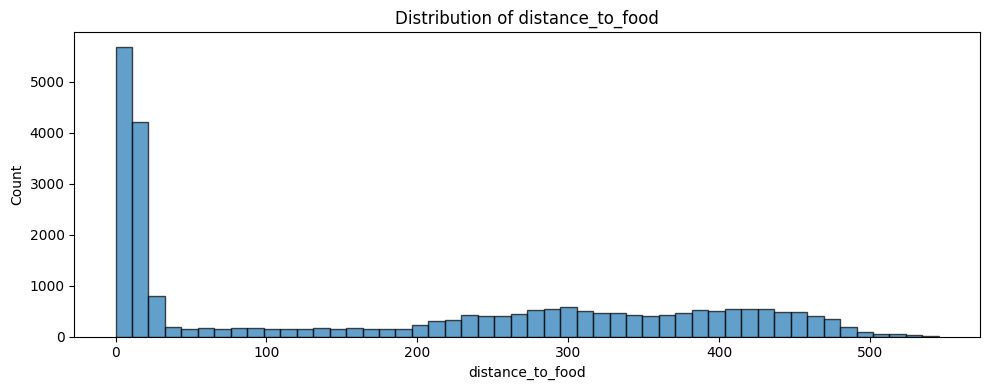

In [22]:
# Get distribution of a property (if any exist)
if len(props) > 0:
    property_id = props.iloc[0]["property_id"]
    print(f"Getting distribution for: {property_id}")

    dist = query.get_property_distributions(
        episode_id=episode_id, property_ids=[property_id]
    )

    if len(dist) > 0:
        print("\nDistribution statistics:")
        print(f"  Count: {len(dist)}")
        print(f"  Mean: {dist['value_float'].mean():.3f}")
        print(f"  Std: {dist['value_float'].std():.3f}")
        print(f"  Min: {dist['value_float'].min():.3f}")
        print(f"  Max: {dist['value_float'].max():.3f}")

        # Plot histogram
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(dist["value_float"], bins=50, edgecolor="black", alpha=0.7)
        ax.set_xlabel(property_id)
        ax.set_ylabel("Count")
        ax.set_title(f"Distribution of {property_id}")
        plt.tight_layout()
        plt.show()
else:
    print("No extended properties available for this episode")

2026-02-23 15:30:10 | INFO     | collab_env.data.db.query_backend:_execute_query:112 - Executing query 'get_extended_properties_timeseries' with params: {'episode_id': 'episode-0000-session-2d-boid_food_basic', 'window_size': 10, 'start_time': None, 'end_time': None, 'agent_type': 'agent', 'lower_quantile': 0.1, 'upper_quantile': 0.9}
2026-02-23 15:30:10 | INFO     | collab_env.data.db.query_backend:_execute_query:145 - Query 'get_extended_properties_timeseries' completed in 0.176s: 120 rows returned


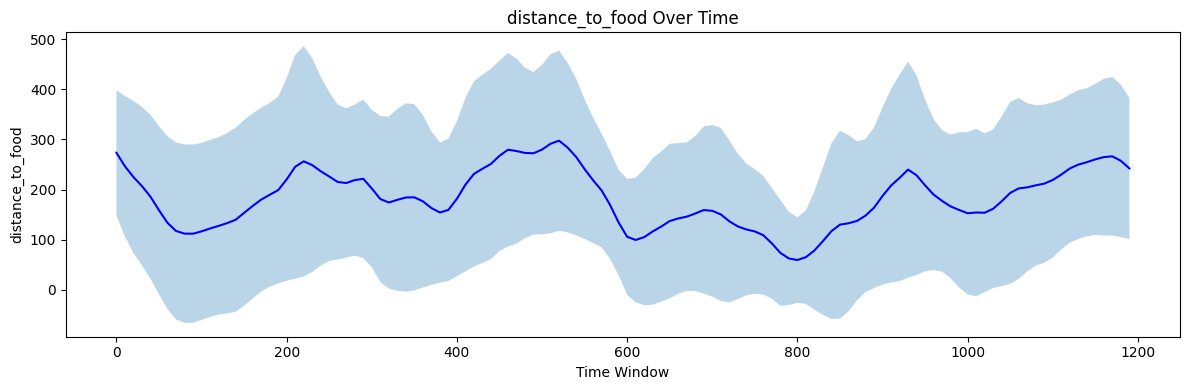

In [23]:
# Get time series of extended properties (windowed)
if len(props) > 0:
    property_id = props.iloc[0]["property_id"]

    timeseries = query.get_extended_properties_timeseries(
        episode_id=episode_id, window_size=10, property_ids=[property_id]
    )

    if len(timeseries) > 0:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.fill_between(
            timeseries["time_window"],
            timeseries["avg_value"] - timeseries["std_value"],
            timeseries["avg_value"] + timeseries["std_value"],
            alpha=0.3,
        )
        ax.plot(timeseries["time_window"], timeseries["avg_value"], "b-")
        ax.set_xlabel("Time Window")
        ax.set_ylabel(property_id)
        ax.set_title(f"{property_id} Over Time")
        plt.tight_layout()
        plt.show()

## Cleanup

In [24]:
# Close database connection
query.close()
print("Connection closed")

2026-02-23 15:30:10 | INFO     | collab_env.data.db.query_backend:close:91 - Closing database connection...
2026-02-23 15:30:10 | INFO     | collab_env.data.db.db_loader:close:231 - Database connection closed


Connection closed


## Troubleshooting

### "Connection refused" error
- Make sure Cloud SQL Proxy is running in another terminal
- Check that port 5433 is not in use: `lsof -i :5433`

### "Permission denied" for secrets
- Run `gcloud auth application-default login`
- Verify project: `gcloud config get-value project`

### Package import errors
- Ensure you installed from the correct branch:
  ```bash
  pip install "collab-env[db] @ git+https://github.com/BasisResearch/collab-environment.git@db-eda-dashboard"
  ```